# Calibration inspection

Plots real, synthetic (uncalibrated), and calibrated IMU signals for a single capture.
The real signal is downsampled to the virtual FPS before plotting so amplitudes are comparable.

In [16]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import numpy as np
import matplotlib.pyplot as plt
import evaluation.utils as utils_module
utils_module = importlib.reload(utils_module)

plt.style.use("seaborn-v0_8-whitegrid")

In [17]:
# --- configuration -----------------------------------------------------------
OUTPUT_ROOT  = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu"
DOMAIN       = "10ms"
USER_ID      = 2
TAG_NUMBER   = 1
TAKE_ID      = None
SIGNAL_GROUP = "acc"          # "acc" or "gyro"
SENSOR_NAME  = "right_forearm"        # single sensor: "waist", "head", "right_forearm", "left_forearm"
TIME_RANGE_SEC = None         # None = full clip, or e.g. (5.0, 15.0)
FIGSIZE      = (18, 4)
LINE_WIDTH   = 1.2
# -----------------------------------------------------------------------------

CAPTURES_DF = utils_module.build_exported_capture_table(OUTPUT_ROOT)
capture_row = utils_module.select_capture_row(
    CAPTURES_DF, domain=DOMAIN, user_id=USER_ID, tag_number=TAG_NUMBER, take_id=TAKE_ID
)

clip_dir = Path(capture_row["clip_dir"])
pose_dir = Path(capture_row["pose_dir"])
print("clip_id:", capture_row["clip_id"])
print("clip_dir:", clip_dir)
print("pose_dir:", pose_dir)

clip_id: robot_emotions_10ms_u02_tag01
clip_dir: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu/10ms/user_02/robot_emotions_10ms_u02_tag01
pose_dir: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu/10ms/user_02/robot_emotions_10ms_u02_tag01/pose/virtual_imu


In [18]:
from pose_module.processing.frequency_alignment import prepare_real_signal_for_virtual_comparison

CHANNEL_GROUP_TO_LABELS = {"acc": ("ax", "ay", "az"), "gyro": ("gx", "gy", "gz")}
COLORS = {"real": "#2196F3", "virtual": "#FF5722", "calibrated": "#4CAF50"}

real_data = utils_module.load_real_capture(clip_dir)
virt_data = utils_module.load_virtual_capture(pose_dir, filename="virtual_imu.npz")

cal_path = pose_dir / "virtual_imu_calibrated.npz"
if not cal_path.exists():
    raise FileNotFoundError(f"Calibrated file not found: {cal_path}")
cal_data = utils_module.load_virtual_capture(pose_dir, filename="virtual_imu_calibrated.npz")

real_slice = slice(0, 3) if SIGNAL_GROUP == "acc" else slice(3, 6)
real_values = real_data["imu"][:, :, real_slice]  # [T, S, 3]

real_bundle = prepare_real_signal_for_virtual_comparison(
    real_timestamps_sec=real_data["timestamps_sec"],
    real_values=real_values,
    virtual_timestamps_sec=virt_data["timestamps_sec"],
)
real_t   = real_bundle["timestamps_sec"]
real_acc = real_bundle["values"]

virt_t   = virt_data["timestamps_sec"]
virt_acc = virt_data[SIGNAL_GROUP]
cal_acc  = cal_data[SIGNAL_GROUP]

utils_module.resolve_selected_sensors([SENSOR_NAME], real_data["sensor_names"])
utils_module.resolve_selected_sensors([SENSOR_NAME], virt_data["sensor_names"])
real_name_to_idx = {n: i for i, n in enumerate(real_data["sensor_names"])}
virt_name_to_idx = {n: i for i, n in enumerate(virt_data["sensor_names"])}

freq_summary = real_bundle["summary"]
print(f"Real original:  {freq_summary['real_original_frequency_hz']:.1f} Hz → downsampled to {freq_summary['real_plot_frequency_hz']:.1f} Hz")
print(f"Virtual:        {freq_summary['virtual_frequency_hz']:.1f} Hz")
print(f"Sensor:         {SENSOR_NAME}")

Real original:  111.1 Hz → downsampled to 30.0 Hz
Virtual:        30.0 Hz
Sensor:         right_forearm


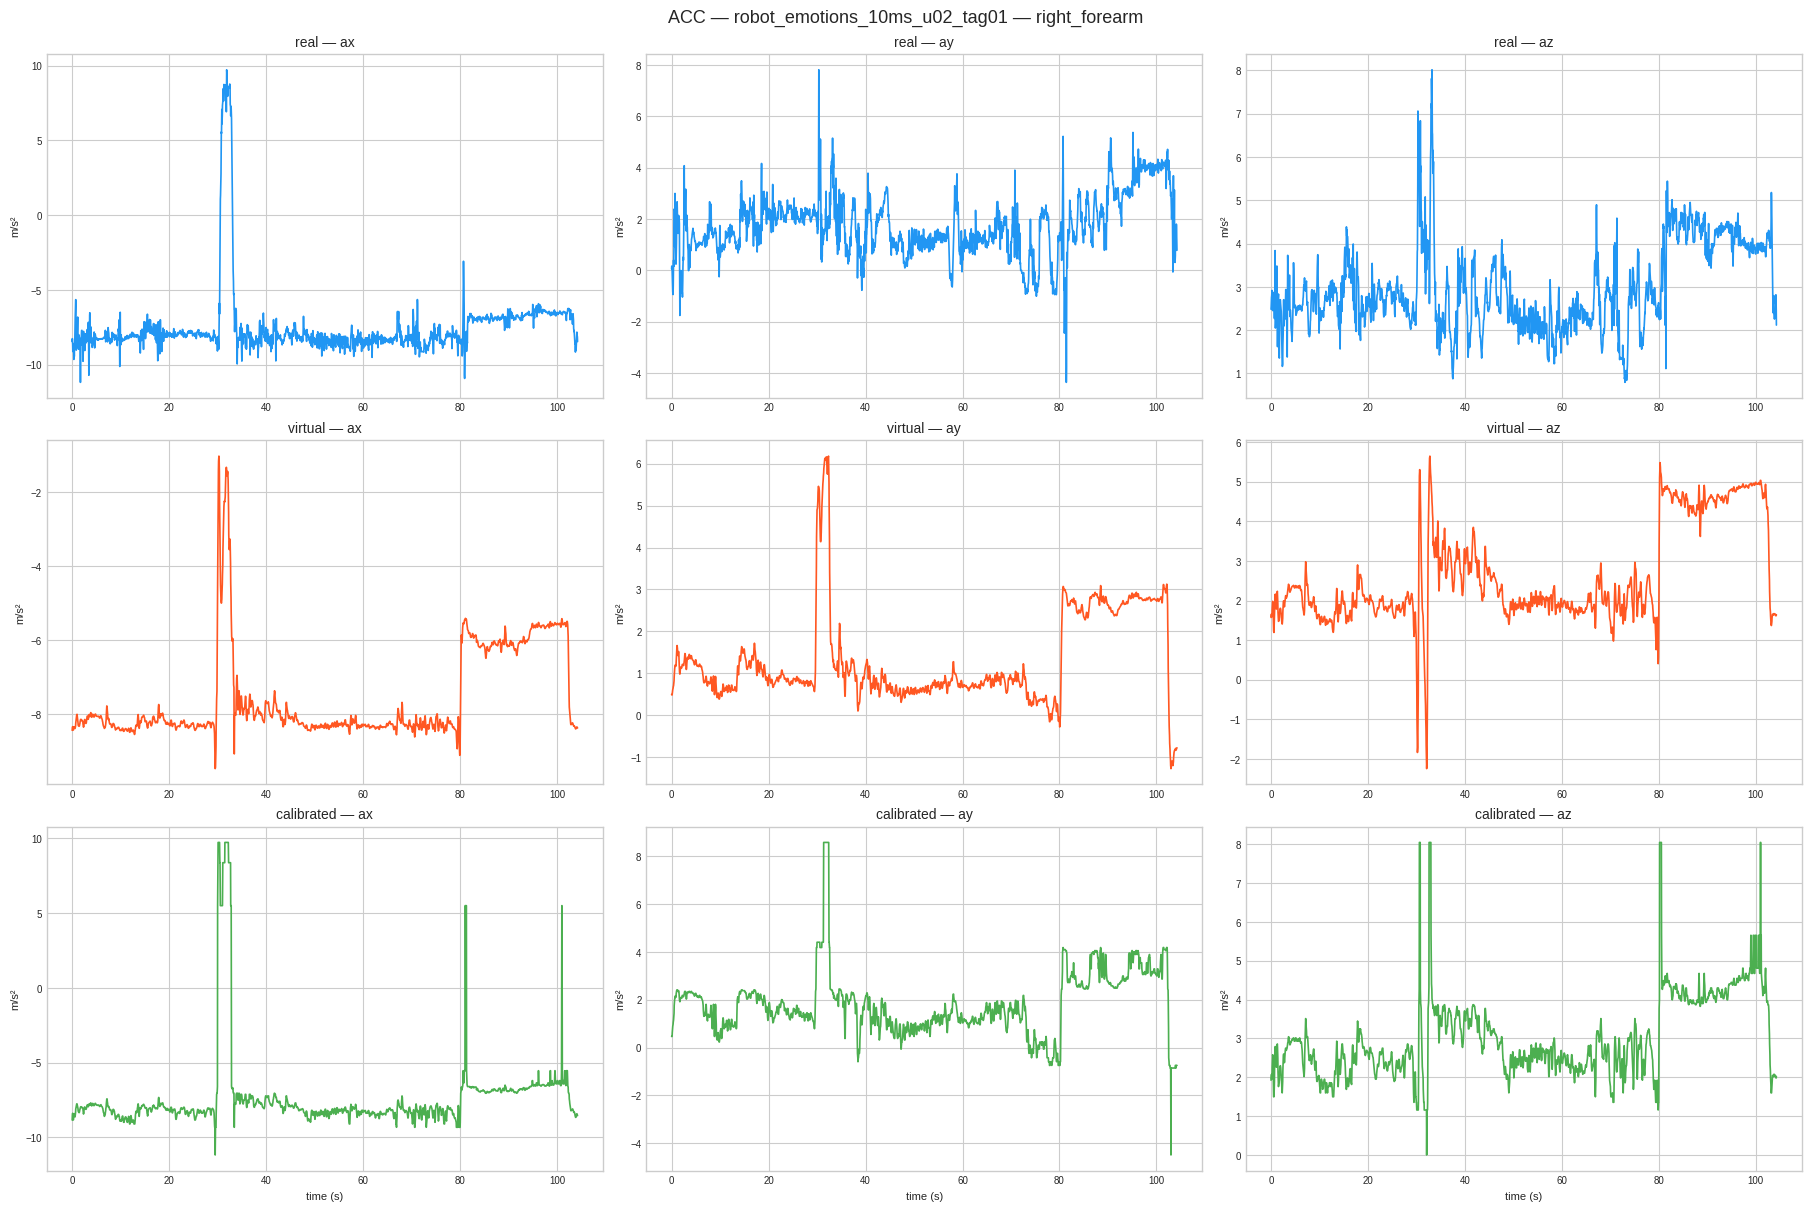

In [19]:
# Time-series: 3 rows (real / virtual / calibrated), 3 columns (x / y / z)
component_labels = CHANNEL_GROUP_TO_LABELS[SIGNAL_GROUP]
unit = "m/s²" if SIGNAL_GROUP == "acc" else "rad/s"
ri = real_name_to_idx[SENSOR_NAME]
vi = virt_name_to_idx[SENSOR_NAME]

row_labels  = ["real", "virtual", "calibrated"]
row_data    = [(real_t, real_acc[:, ri, :]), (virt_t, virt_acc[:, vi, :]), (virt_t, cal_acc[:, vi, :])]
row_colors  = [COLORS["real"], COLORS["virtual"], COLORS["calibrated"]]

fig, axes = plt.subplots(3, 3, figsize=(FIGSIZE[0], FIGSIZE[1] * 3),
                         sharey=False, constrained_layout=True)
fig.suptitle(f"{SIGNAL_GROUP.upper()} — {capture_row['clip_id']} — {SENSOR_NAME}", fontsize=13)

for row, (label, (t, vals), color) in enumerate(zip(row_labels, row_data, row_colors)):
    for col, comp in enumerate(component_labels):
        ax = axes[row][col]
        t_plot, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax.plot(t_plot, v_plot, color=color, lw=LINE_WIDTH)
        ax.set_title(f"{label} — {comp}", fontsize=10)
        ax.set_ylabel(unit, fontsize=8)
        ax.tick_params(labelsize=7)
        if row == 2:
            ax.set_xlabel("time (s)", fontsize=8)

plt.show()

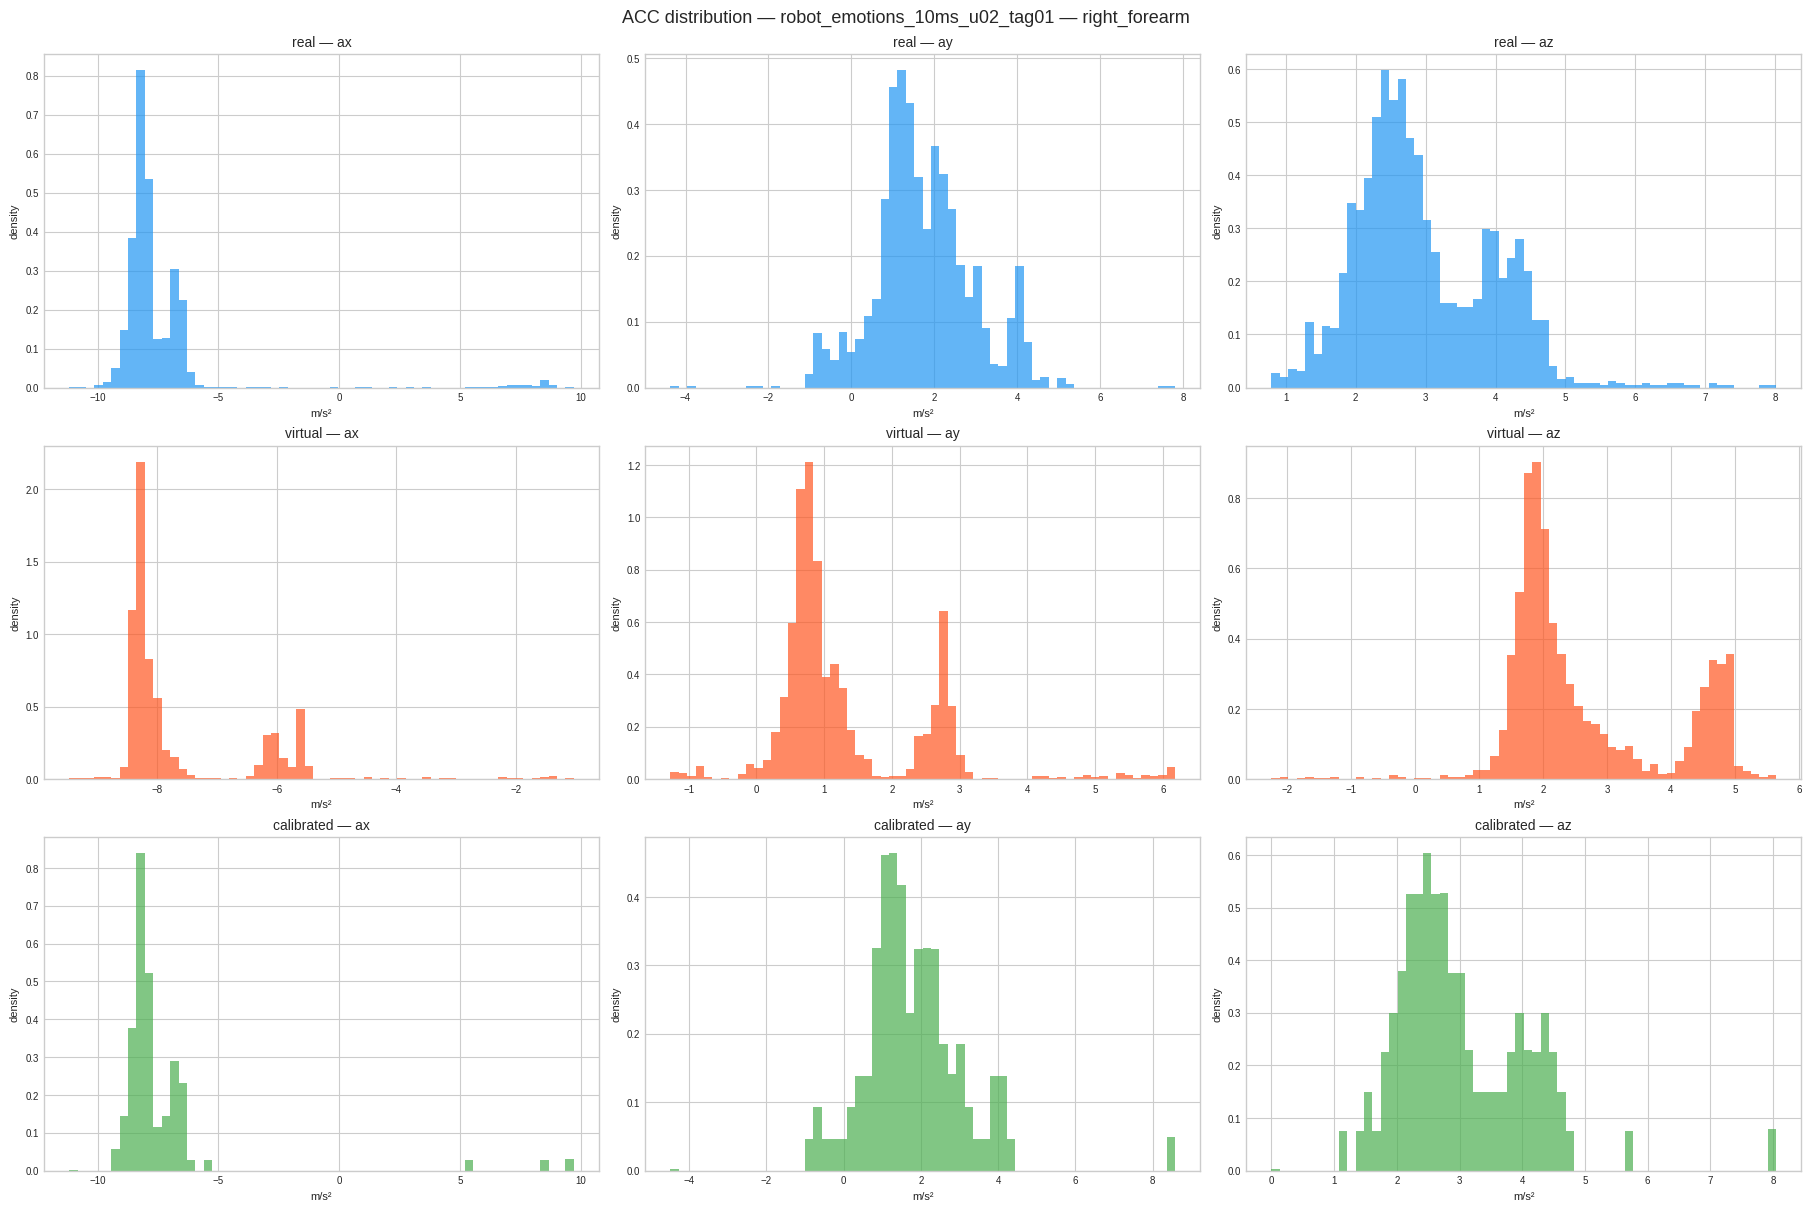

In [20]:
# Distribution (histogram): 3 rows (real / virtual / calibrated), 3 columns (x / y / z)
fig, axes = plt.subplots(3, 3, figsize=(FIGSIZE[0], FIGSIZE[1] * 3), constrained_layout=True)
fig.suptitle(f"{SIGNAL_GROUP.upper()} distribution — {capture_row['clip_id']} — {SENSOR_NAME}", fontsize=13)

for row, (label, (t, vals), color) in enumerate(zip(row_labels, row_data, row_colors)):
    for col, comp in enumerate(component_labels):
        ax = axes[row][col]
        _, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax.hist(v_plot, bins=60, color=color, alpha=0.7, density=True)
        ax.set_title(f"{label} — {comp}", fontsize=10)
        ax.set_xlabel(unit, fontsize=8)
        ax.set_ylabel("density", fontsize=8)
        ax.tick_params(labelsize=7)

plt.show()